# 23 — Orthogonal rights across two periods

**Goal.** Build a small, *orthogonal* battery of rights that lets us read the partial order between social groups cleanly. Two periods only — **Classical (500–360 BCE)** and **Roman (165 BCE – 205 CE)** — to give the longest diachronic span.

**Why orthogonal rights.** A partial order is interesting precisely when some pairs of items have no required precedence — like socks/underwear (no order) vs socks/shoes (socks first). If every right we measure is just a sub-flavour of every other (e.g. *political power* ⊇ *vote* ⊇ *speak in assembly*), the diagram only shows nesting, not real social structure.

So we pick one canonical right per **distinct domain** — civic franchise, civic office, public speech, marriage, property transfer, legal due process, bodily safety, mobility — and drop vague umbrella concepts (`Political power`, `Right to citizenship`) that subsume the others.

**Specificity.** Each chosen right is something a marked group could plausibly *gain in the future* (or be shown to have already gained partially), so the diagram has room to evolve as new data is added.

In [1]:
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd
from matplotlib.patches import Patch

pd.set_option('display.max_colwidth', 120)

DATA_PATH = Path('../data/rules_dataset_april_2026.tsv')

PERIOD_MAP = {
    'Classical (500–360 BCE)':                      'Classical (500–360 BCE)',
    'Hellenistic & Early Roman (165 BCE – 105 CE)': 'Roman (165 BCE – 205 CE)',
    'High Roman Empire (135–205 CE)':               'Roman (165 BCE – 205 CE)',
}
PERIOD_ORDER = [
    'Classical (500–360 BCE)',
    'Roman (165 BCE – 205 CE)',
]

GREEK_POLITIES = {
    'Classical Athens', 'Hellenistic Athens', 'Archaic Athens',
    'Archaic Athens (Solonic)', 'Archaic Athens (Draconian)',
    'Archaic Athens (Peisistratid)', 'Archaic Athens (Pre-Solonic)',
    'Classical Athens (Solonic)', 'Classical Athens (Cleisthenic)',
    'Classical Athens (Eleusis)', 'Classical Athens (The Four Hundred)',
    'Classical Athens (The Five Thousand)', 'Classical Athens (the Five Thousand)',
    'Classical Sparta', 'Sparta', 'Archaic Sparta',
    'Classical Greece', 'Ancient Greece', 'Hellenistic Greece', 'Hellenistic Greek states',
    'Classical Thebes', 'Syracuse', 'Sicyon', 'Corinth', 'Aegina',
    'Mantineia', 'Mytilene', 'Oreus', 'Acragas', 'Delphi', 'Crete',
    'Chalcidice', 'Salamis (Cyprus)', 'Ionia and Pontus', 'Tarsus',
    'League of Corinth', 'Achaean League', 'Delphic Amphictyonic League',
    'Hellenistic Macedon', 'Macedonian Empire', 'Seleucid Empire',
    'Hierapolis (Syria)', 'Hellenistic Hierapolis',
    'Mythological / legendary setting',
}

GROUP_DROP   = {'Other'}
GROUP_RENAME = {'The poor': 'The poor / multitude', 'The multitude': 'The poor / multitude'}

RESOURCE_BUCKET = {
    'Right to own land':                          'Right to own property',
    'Right to retain own earnings':               'Right to retain property',
    'Right to dispose of property':               'Right to dispose / inherit property',
    'Right to inherit property':                  'Right to dispose / inherit property',
    'Right to inherit divine covenant':           'Right to dispose / inherit property',
    'Right to address the assembly':              'Right to public speech',
    'Right to speak first in assembly':           'Right to public speech',
    'Right to free speech':                       'Right to public speech',
    'Right to remuneration for office':           'Eligibility for public office',
    'Right to reside in the city':                'Right to reside / freedom of movement',
    'Right to freedom of movement':               'Right to reside / freedom of movement',
    'Right to a dowry':                           'Right to marriage / dowry',
    'Right to marry':                             'Right to marriage / dowry',
    'Right to professional judgement':            'Right to a legal trial',
    'Right to valid professional opinion':        'Right to a legal trial',
    'Right to military protection':               'Right to bear arms / military protection',
    'Right to bear arms':                         'Right to bear arms / military protection',
    'Protection from arbitrary banishment':       'Protection from banishment / prosecution',
    'Protection from legal prosecution':          'Protection from banishment / prosecution',
    'Protection from capital punishment':         'Protection from capital / corporal punishment',
    'Protection from corporal punishment':        'Protection from capital / corporal punishment',
    'Exemption from compulsory public financing': 'Exemption from taxes / public financing',
    'Exemption from public service financing':    'Exemption from taxes / public financing',
    'Exemption from taxes':                       'Exemption from taxes / public financing',
    'Exemption from manual labor':                'Exemption from compulsory service',
    'Exemption from military service':            'Exemption from compulsory service',
}

OPPOSITE_GROUP = {
    'Women':                'Men',  'Wives':                'Men',
    'Men':                  None,   'Minors':               'Men',
    'Elders':               'Men',  'Orphans':              'Heirs',
    'Heirs':                None,
    'Slaves':               'Citizens', 'Foreigners':       'Citizens',
    'Exiles':               'Citizens', 'Citizens':         None,
    'Macedonians':          'Greeks',   'Scythians':         'Greeks',
    'Syrians':              'Greeks',   'Greeks':            None,
    'Spartans':             None,
    'The poor / multitude': 'The wealthy', 'The wealthy':    None,
    'Sick':                 'Men',  'Physicians':           None,
    'Kings':                None,   'Nobles':               None,
    'Magistrates':          None,   'Artisans':             None,
    'Poets':                None,   'Priests':              None,
    'Soldiers':             None,   'Sailors':              None,
    'Philosophers':         None,   'The educated':         None,
    'Christians':           None,   'Jews':                 None,
    'Romans':               None,
}

CANONICAL_GROUPS = ['Citizens', 'Women', 'Slaves', 'Foreigners']
GROUP_TO_TARGETS = {
    'Citizens': ['Citizens'], 'Foreigners': ['Foreigners'], 'Slaves': ['Slaves'],
    'Exiles': ['Citizens'], 'Men': ['Citizens'], 'Women': ['Women'], 'Wives': ['Women'],
    'Nobles': ['Citizens'], 'Magistrates': ['Citizens'], 'Kings': ['Citizens'],
    'Heirs': ['Citizens'], 'Spartans': ['Citizens'], 'Priests': ['Citizens'],
    'Soldiers': ['Citizens'], 'Sailors': ['Citizens'], 'Artisans': ['Citizens'],
    'Physicians': ['Citizens'], 'Philosophers': ['Citizens'], 'Poets': ['Citizens'],
    'The educated': ['Citizens'], 'The wealthy': ['Citizens'],
    'The poor / multitude': ['Citizens'], 'Minors': ['Citizens'], 'Orphans': ['Citizens'],
    'Elders': ['Citizens'], 'Sick': ['Citizens'], 'Greeks': ['Citizens'],
    'Macedonians': ['Foreigners'], 'Scythians': ['Foreigners'], 'Syrians': ['Foreigners'],
    'Christians': ['Citizens', 'Foreigners', 'Women'],
    'Jews':       ['Citizens', 'Foreigners', 'Women'],
    'Romans': [],
}

MIN_RULES_PER_CELL = 1
MIN_RIGHTS         = 1
OVERLAP_MIN        = 0.5

COLOR_MORE  = '#1f4e79'
COLOR_FLIP  = '#c97c2e'
COLOR_BOTH  = '#5a3a8a'
COLOR_EMPTY = '#f2f2f2'

In [2]:
df_raw = pd.read_csv(DATA_PATH, sep='\t')

def atoms(s):
    if pd.isna(s):
        return []
    return [x.strip() for x in str(s).split(';') if x.strip()]

base = (df_raw
          .dropna(subset=['period', 'group_meta', 'resource_meta', 'rule_polity', 'directionality'])
          .assign(period=lambda d: d['period'].map(PERIOD_MAP))
          .dropna(subset=['period']))
base = base[base['rule_polity'].isin(GREEK_POLITIES)]
base = base.assign(resource_bucket=base['resource_meta'].map(lambda r: RESOURCE_BUCKET.get(r, r)))
base = base.assign(group_cat=base['group_meta'].apply(atoms)).explode('group_cat')
base = base[~base['group_cat'].isin(GROUP_DROP)]
base = base.assign(group_cat=base['group_cat'].replace(GROUP_RENAME))

more_rows = base[base['directionality'] == 'MORE'][['period', 'group_cat', 'resource', 'resource_bucket', 'rule']]
less_rows = base[base['directionality'] == 'LESS'][['period', 'group_cat', 'resource', 'resource_bucket', 'rule']]

flipped = less_rows.assign(group_cat=less_rows['group_cat'].map(OPPOSITE_GROUP)).dropna(subset=['group_cat'])

def to_targets(frame):
    out = frame.assign(group=frame['group_cat'].map(lambda g: GROUP_TO_TARGETS.get(g, [])))
    out = out.explode('group').dropna(subset=['group'])
    return out[['period', 'group', 'resource', 'resource_bucket', 'rule']]

more_t    = to_targets(more_rows)
flipped_t = to_targets(flipped)

positive = pd.concat([more_t.assign(origin='MORE'),
                      flipped_t.assign(origin='flipped LESS')],
                     ignore_index=True)

positive.shape, positive['origin'].value_counts().to_dict()

((349, 6), {'MORE': 274, 'flipped LESS': 75})

## Orthogonal rights — one canonical concept per social domain

Each row below is from a **distinct domain**, so no right is a sub-flavour of another. The table also gives a one-line *gainability* note — what it means for a marked group to acquire this right.

| Right (bucket label)                              | Domain                | Why orthogonal                                                              | Gainable as |
|---------------------------------------------------|------------------------|-----------------------------------------------------------------------------|-------------|
| Right to vote in the Ekklesia                     | Civic franchise        | Distinct from holding office (citizens voted but didn't hold magistracies)  | Suffrage extension |
| Eligibility for public office                     | Civic office           | Distinct from voting — requires property/age qualifications                 | Office quotas |
| Right to public speech                            | Public voice           | Distinct from voting and office; speech can exist without either            | Free-press / parrhesia |
| Right to dispose / inherit property               | Economic transfer      | Distinct from owning — disposition rights act *on* property                 | Probate reform |
| Right to marriage / dowry                         | Marital agency         | Distinct from property — agency over partner & dowry                        | Marital consent |
| Right to a legal trial                            | Due process            | Distinct from all above — procedural access to justice                      | Right to be heard |
| Protection from capital / corporal punishment     | Bodily safety          | Distinct from due process — substantive bodily inviolability                | Habeas corporis |
| Right to reside / freedom of movement             | Mobility               | Distinct from civic rights — physical presence in / across territory        | Right of return / domicile |
| Access to religious rites                         | Religious participation| Distinct from civic / legal — public-cult participation                     | Religious freedom |
| Protection from enslavement                       | Anti-slavery           | Distinct from corporal-punishment protection — *being owned* vs *being hurt* | Abolition |
| Exemption from compulsory service                 | Labour exemption       | Distinct from arms / military — freedom from forced labour & conscription   | End of corvée |

*Dropped because too vague:* `Political power` (subsumes vote + office + speech), `Right to citizenship` (meaning shifts radically between Classical deme-registration and Roman universal grant).

*Dropped because too nested:* `Right to own property`, `Right to retain property` (both subsumed by *dispose / inherit*); `Access to public honors` (heterogeneous — subsidies → state maintenance → Prytaneum); `Access to the gymnasium` (civic athletics → social-status marker); `Right to bodily autonomy` (citizen physical inviolability vs slave / woman sexual integrity); `Protection from banishment / prosecution` (banishment vs harassment collapsed); `Exemption from taxes / public financing` (elite-only privilege, no gainability for marked groups).

In [3]:
ORTHOGONAL_RIGHTS = [
    'Right to vote in the Ekklesia',
    'Eligibility for public office',
    'Right to public speech',
    'Right to dispose / inherit property',
    'Right to marriage / dowry',
    'Right to a legal trial',
    'Protection from capital / corporal punishment',
    'Right to reside / freedom of movement',
    'Access to religious rites',
    'Protection from enslavement',
    'Exemption from compulsory service',
]
len(ORTHOGONAL_RIGHTS)

11

## Verify — what does each orthogonal right actually mean in each period?

Per right, list the granular `resource` strings attested in each of the two periods. This is the semantic-stability check: if Classical mentions e.g. *Right to vote in the Assembly* and Roman mentions *Right to vote in the assembly*, the meaning is invariant.

In [4]:
for right in ORTHOGONAL_RIGHTS:
    print(f'\n=== {right} ===')
    for p in PERIOD_ORDER:
        sub = positive[(positive['resource_bucket'] == right) & (positive['period'] == p)]
        granular = sub['resource'].value_counts()
        if len(granular) == 0:
            print(f'  [{p.split(" (")[0]}]  (no rules)')
            continue
        print(f'  [{p.split(" (")[0]}]')
        for r, c in granular.head(5).items():
            print(f'      {c:3d}  {r}')


=== Right to vote in the Ekklesia ===
  [Classical]
        2  Right to vote in the Assembly
        1  Right to vote in the Ekklesia
  [Roman]
        2  Right to equal suffrage
        1  Right to vote in the assembly
        1  Right to elect officials
        1  Right to vote in ostracism
        1  Right to vote in the Ekklesia

=== Eligibility for public office ===
  [Classical]
        7  Eligibility for the archonship
        2  Eligibility for the Council
        2  Eligibility for the gymnasiarchy
        2  Access to multiple paid tribunals
        1  Right to the throne
  [Roman]
        2  Eligibility for the archonship
        2  Eligibility for the kingship
        2  Exclusive eligibility for kingship
        2  Eligibility for the archonship and public offices
        1  Eligibility for the cavalry

=== Right to public speech ===
  [Classical]
        3  Right to address the Assembly
        2  Permission to influence through persuasion
        1  Right of speech in a

## Partial order — two-period Hasse

In [5]:
positive_c = positive[positive['resource_bucket'].isin(ORTHOGONAL_RIGHTS)]
groups     = [g for g in CANONICAL_GROUPS if g in set(positive_c['group'])]

cell_support = (positive_c
                  .groupby(['period', 'group', 'resource_bucket'])
                  .size()
                  .rename('n_rules')
                  .reset_index())
rights_long = pd.DataFrame(
    [(p, g, r) for p in PERIOD_ORDER for g in groups for r in ORTHOGONAL_RIGHTS],
    columns=['period', 'group', 'resource_bucket'],
).merge(cell_support, on=['period', 'group', 'resource_bucket'], how='left')
rights_long['n_rules']   = rights_long['n_rules'].fillna(0).astype(int)
rights_long['has_right'] = (rights_long['n_rules'] >= MIN_RULES_PER_CELL).astype(int)

def right_sets(period):
    sub = rights_long[(rights_long['period'] == period) & (rights_long['has_right'] == 1)]
    sets = {g: frozenset(grp['resource_bucket']) for g, grp in sub.groupby('group')}
    return {g: s for g, s in sets.items() if len(s) >= MIN_RIGHTS}

def approx_graph(sets, overlap_min=OVERLAP_MIN):
    classes = {}
    for g, s in sets.items():
        classes.setdefault(s, []).append(g)
    nodes = list(classes.keys())
    G = nx.DiGraph()
    for s in nodes:
        G.add_node(s, size=len(s))
    for a, b in combinations(nodes, 2):
        big, small = (b, a) if len(b) > len(a) else (a, b)
        if len(big) == len(small):
            continue
        if len(small & big) / len(small) >= overlap_min:
            G.add_edge(small, big)
    return nx.transitive_reduction(G), classes

def topological_positions(G):
    depth = {n: 0 for n in G.nodes}
    for n in reversed(list(nx.topological_sort(G))):
        for succ in G.successors(n):
            if depth[n] < depth[succ] + 1:
                depth[n] = depth[succ] + 1
    max_d = max(depth.values()) if depth else 0
    levels = {}
    for n in G.nodes:
        levels.setdefault(max_d - depth[n], []).append(n)
    pos = {}
    for y, nodes in levels.items():
        nodes = sorted(nodes, key=lambda s: sorted(s))
        for i, n in enumerate(nodes):
            pos[n] = ((i + 1) / (len(nodes) + 1), y)
    return pos

{p: len(right_sets(p)) for p in PERIOD_ORDER}

{'Classical (500–360 BCE)': 4, 'Roman (165 BCE – 205 CE)': 3}

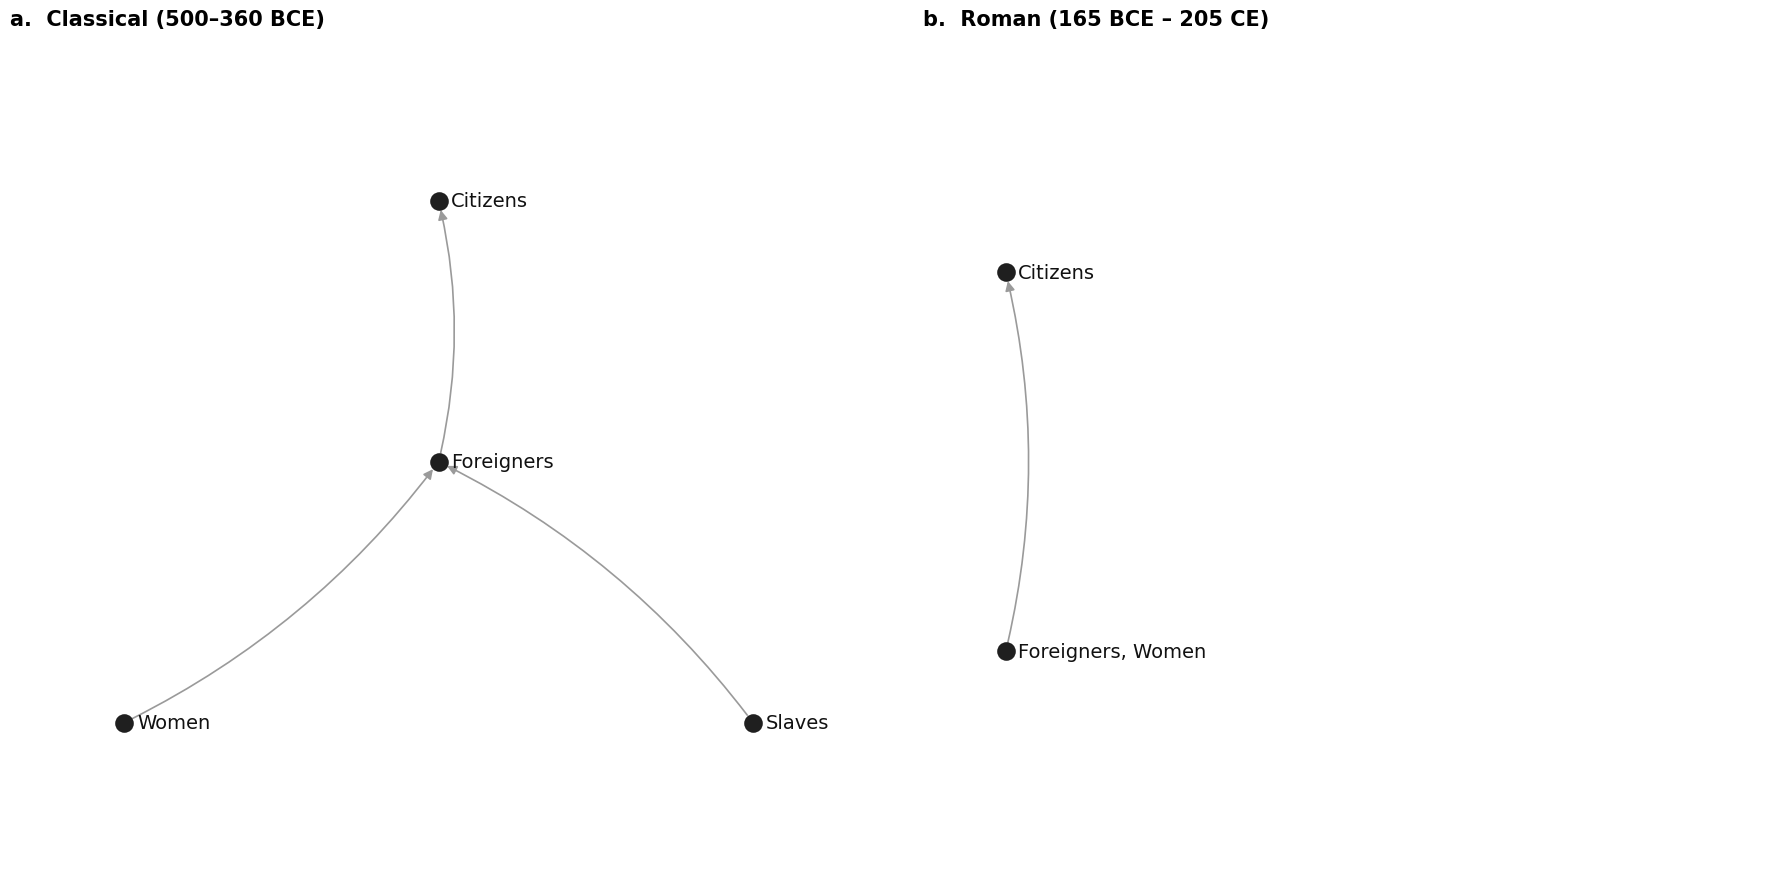

In [6]:
plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'axes.labelsize':  14,
    'axes.titlesize':  15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 12,
})
NODE_SIZE = 180
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for letter, ax, period in zip('ab', axes, PERIOD_ORDER):
    sets = right_sets(period)
    G, classes = approx_graph(sets)
    pos = topological_positions(G)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=NODE_SIZE, node_color='#1f1f1f', linewidths=0)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#9a9a9a', width=1.2,
                            arrows=True, arrowstyle='-|>', arrowsize=14,
                            node_size=NODE_SIZE, connectionstyle='arc3,rad=0.12',
                            min_source_margin=5, min_target_margin=5)
    for n, (x, y) in pos.items():
        ax.annotate(', '.join(classes[n]), xy=(x, y), xytext=(9, 0),
                    textcoords='offset points', ha='left', va='center',
                    fontsize=14, color='#111111')
    ymax = max(y for _, y in pos.values()) if pos else 0
    ax.set_title(f'{letter}.  {period}', fontsize=15, loc='left', pad=14, weight='semibold')
    ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(axis='both', length=0)
    ax.set_ylim(-0.6, ymax + 0.6); ax.margins(x=0.12)
    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)

fig.tight_layout(w_pad=4)
plt.show()

## Rights by origin — positive vs inferred via asymmetric flip

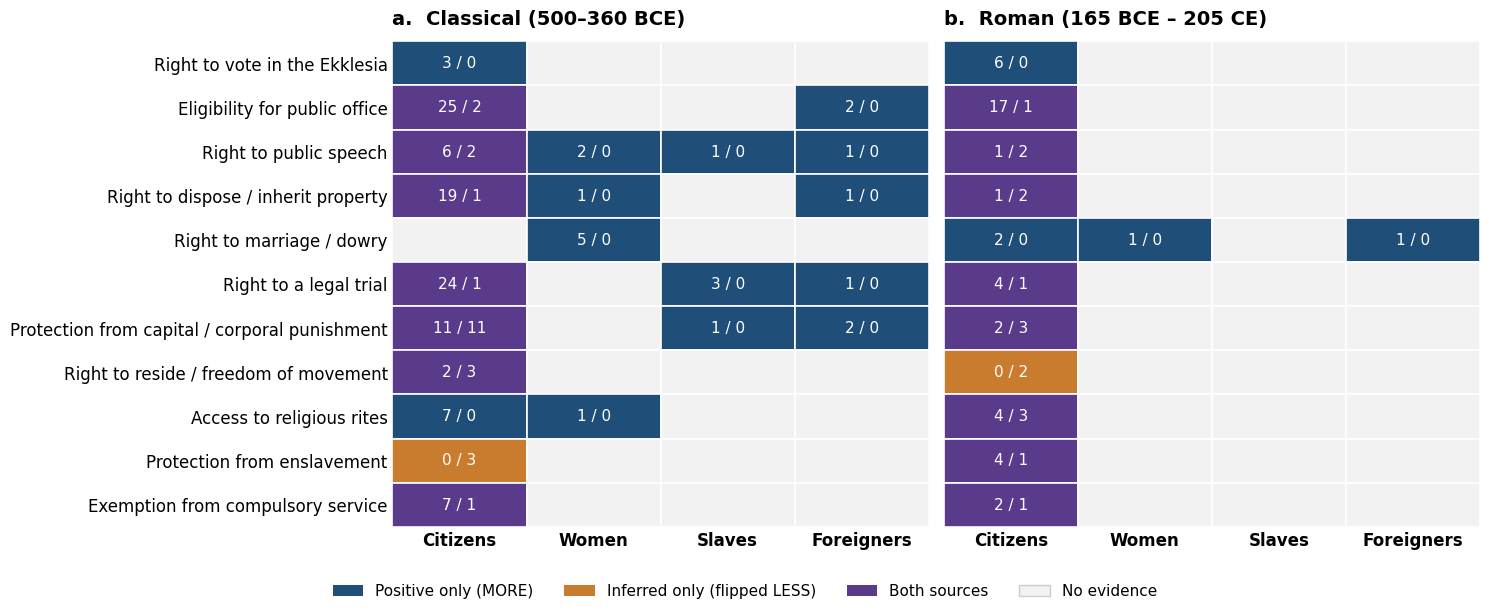

In [7]:
origin_counts = (positive[positive['resource_bucket'].isin(ORTHOGONAL_RIGHTS)]
                 .groupby(['period', 'group', 'resource_bucket', 'origin'])
                 .size()
                 .unstack('origin', fill_value=0)
                 .reset_index())
for col in ('MORE', 'flipped LESS'):
    if col not in origin_counts.columns:
        origin_counts[col] = 0

groups_x = CANONICAL_GROUPS
rights_y = ORTHOGONAL_RIGHTS

def cell_color(m, f):
    if m > 0 and f > 0: return COLOR_BOTH
    if m > 0:           return COLOR_MORE
    if f > 0:           return COLOR_FLIP
    return COLOR_EMPTY

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for letter, ax, period in zip('ab', axes, PERIOD_ORDER):
    sub = origin_counts[origin_counts['period'] == period]
    n_rows, n_cols = len(rights_y), len(groups_x)
    M = np.zeros((n_rows, n_cols), dtype=int)
    F = np.zeros((n_rows, n_cols), dtype=int)
    for _, r in sub.iterrows():
        if r['group'] not in groups_x or r['resource_bucket'] not in rights_y:
            continue
        i = rights_y.index(r['resource_bucket'])
        j = groups_x.index(r['group'])
        M[i, j] = int(r.get('MORE', 0))
        F[i, j] = int(r.get('flipped LESS', 0))
    for i in range(n_rows):
        for j in range(n_cols):
            color = cell_color(M[i, j], F[i, j])
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                       facecolor=color, edgecolor='white', linewidth=1.2))
            if M[i, j] or F[i, j]:
                txt_color = '#ffffff' if color != COLOR_EMPTY else '#111111'
                ax.text(j, i, f'{M[i,j]} / {F[i,j]}',
                        ha='center', va='center', fontsize=11, color=txt_color)
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(groups_x, rotation=0, fontsize=12, weight='semibold')
    ax.set_yticks(range(n_rows))
    if letter == 'a':
        ax.set_yticklabels(rights_y, fontsize=12)
    else:
        ax.set_yticklabels([''] * n_rows)
    ax.tick_params(axis='both', length=0)
    ax.set_title(f'{letter}.  {period}', fontsize=14, loc='left', pad=12, weight='semibold')
    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)

legend_handles = [
    Patch(facecolor=COLOR_MORE,  label='Positive only (MORE)'),
    Patch(facecolor=COLOR_FLIP,  label='Inferred only (flipped LESS)'),
    Patch(facecolor=COLOR_BOTH,  label='Both sources'),
    Patch(facecolor=COLOR_EMPTY, edgecolor='#cccccc', label='No evidence'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False,
           fontsize=11, bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## Rights per group, per period

In [8]:
for period in PERIOD_ORDER:
    sets = right_sets(period)
    print(f'=== {period} ===')
    for g in CANONICAL_GROUPS:
        if g in sets:
            rights = sorted(sets[g])
            print(f'{g} ({len(rights)}) = {{ {", ".join(rights)} }}')
        else:
            print(f'{g} (—) = {{ }}')
    print()

=== Classical (500–360 BCE) ===
Citizens (10) = { Access to religious rites, Eligibility for public office, Exemption from compulsory service, Protection from capital / corporal punishment, Protection from enslavement, Right to a legal trial, Right to dispose / inherit property, Right to public speech, Right to reside / freedom of movement, Right to vote in the Ekklesia }
Women (4) = { Access to religious rites, Right to dispose / inherit property, Right to marriage / dowry, Right to public speech }
Slaves (3) = { Protection from capital / corporal punishment, Right to a legal trial, Right to public speech }
Foreigners (5) = { Eligibility for public office, Protection from capital / corporal punishment, Right to a legal trial, Right to dispose / inherit property, Right to public speech }

=== Roman (165 BCE – 205 CE) ===
Citizens (11) = { Access to religious rites, Eligibility for public office, Exemption from compulsory service, Protection from capital / corporal punishment, Protectio